In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/yasserh/walmart-dataset/Walmart.csv")

print(df.head())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [2]:
print(df.shape)

(6435, 8)


In [3]:
print(df.dtypes)

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object


In [4]:
# Stores with Weekly Sales greater than 1,000,000
high_sales = df[df["Weekly_Sales"] > 1000000]

print(high_sales)

      Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0         1  05-02-2010    1643690.90             0        42.31       2.572   
1         1  12-02-2010    1641957.44             1        38.51       2.548   
2         1  19-02-2010    1611968.17             0        39.93       2.514   
3         1  26-02-2010    1409727.59             0        46.63       2.561   
4         1  05-03-2010    1554806.68             0        46.50       2.625   
...     ...         ...           ...           ...          ...         ...   
6337     45  17-12-2010    1123282.85             0        30.51       3.140   
6338     45  24-12-2010    1682862.03             0        30.59       3.141   
6386     45  25-11-2011    1170672.94             1        48.71       3.492   
6389     45  16-12-2011    1078905.68             0        39.93       3.413   
6390     45  23-12-2011    1521957.99             0        42.27       3.389   

             CPI  Unemployment  
0     

In [5]:
# Records from Holiday Weeks
holiday_sales = df[df["Holiday_Flag"] == 1]

print(holiday_sales)

      Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
1         1  12-02-2010    1641957.44             1        38.51       2.548   
31        1  10-09-2010    1507460.69             1        78.69       2.565   
42        1  26-11-2010    1955624.11             1        64.52       2.735   
47        1  31-12-2010    1367320.01             1        48.43       2.943   
53        1  11-02-2011    1649614.93             1        36.39       3.022   
...     ...         ...           ...           ...          ...         ...   
6375     45  09-09-2011     746129.56             1        71.48       3.738   
6386     45  25-11-2011    1170672.94             1        48.71       3.492   
6391     45  30-12-2011     869403.63             1        37.79       3.389   
6397     45  10-02-2012     803657.12             1        37.00       3.640   
6427     45  07-09-2012     766512.66             1        75.70       3.911   

             CPI  Unemployment  
1     

In [6]:
# Records from Store 1
store1_data = df[df["Store"] == 1]

print(store1_data)

     Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0        1  05-02-2010    1643690.90             0        42.31       2.572   
1        1  12-02-2010    1641957.44             1        38.51       2.548   
2        1  19-02-2010    1611968.17             0        39.93       2.514   
3        1  26-02-2010    1409727.59             0        46.63       2.561   
4        1  05-03-2010    1554806.68             0        46.50       2.625   
..     ...         ...           ...           ...          ...         ...   
138      1  28-09-2012    1437059.26             0        76.08       3.666   
139      1  05-10-2012    1670785.97             0        68.55       3.617   
140      1  12-10-2012    1573072.81             0        62.99       3.601   
141      1  19-10-2012    1508068.77             0        67.97       3.594   
142      1  26-10-2012    1493659.74             0        69.16       3.506   

            CPI  Unemployment  
0    211.096358    

In [8]:
sorted_df = df.sort_values(
    by="Weekly_Sales",
    ascending=False
)

print(sorted_df)

      Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
1905     14  24-12-2010    3818686.45             0        30.59       3.141   
2763     20  24-12-2010    3766687.43             0        25.17       3.141   
1333     10  24-12-2010    3749057.69             0        57.06       3.236   
527       4  23-12-2011    3676388.98             0        35.92       3.103   
1762     13  24-12-2010    3595903.20             0        34.90       2.846   
...     ...         ...           ...           ...          ...         ...   
4671     33  02-12-2011     220060.35             0        59.12       3.701   
4623     33  31-12-2010     219804.85             1        52.91       3.148   
4675     33  30-12-2011     215359.21             1        51.60       3.428   
4614     33  29-10-2010     213538.32             0        71.34       3.130   
4619     33  03-12-2010     209986.25             0        52.82       3.041   

             CPI  Unemployment  
1905  

In [9]:
sorted_df = df.sort_values(
    by="Weekly_Sales",
    ascending=False
)

print(sorted_df.head())

      Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
1905     14  24-12-2010    3818686.45             0        30.59       3.141   
2763     20  24-12-2010    3766687.43             0        25.17       3.141   
1333     10  24-12-2010    3749057.69             0        57.06       3.236   
527       4  23-12-2011    3676388.98             0        35.92       3.103   
1762     13  24-12-2010    3595903.20             0        34.90       2.846   

             CPI  Unemployment  
1905  182.544590         8.724  
2763  204.637673         7.484  
1333  126.983581         9.003  
527   129.984548         5.143  
1762  126.983581         7.795  


In [10]:
sorted_df = df.sort_values(
    by="Weekly_Sales",
    ascending=False
)

print(sorted_df.head(10))

      Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
1905     14  24-12-2010    3818686.45             0        30.59       3.141   
2763     20  24-12-2010    3766687.43             0        25.17       3.141   
1333     10  24-12-2010    3749057.69             0        57.06       3.236   
527       4  23-12-2011    3676388.98             0        35.92       3.103   
1762     13  24-12-2010    3595903.20             0        34.90       2.846   
1814     13  23-12-2011    3556766.03             0        24.76       3.186   
2815     20  23-12-2011    3555371.03             0        40.19       3.389   
475       4  24-12-2010    3526713.39             0        43.21       2.887   
1385     10  23-12-2011    3487986.89             0        48.36       3.541   
189       2  24-12-2010    3436007.68             0        49.97       2.886   

             CPI  Unemployment  
1905  182.544590         8.724  
2763  204.637673         7.484  
1333  126.983581    

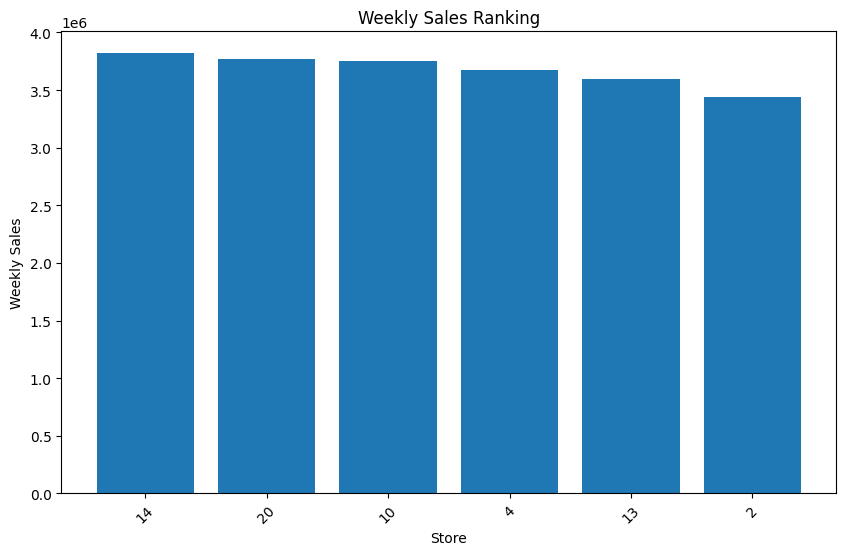

In [11]:
import matplotlib.pyplot as plt

top_10 = df.sort_values(
    by="Weekly_Sales",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10["Store"].astype(str),
    top_10["Weekly_Sales"]
)

plt.xlabel("Store")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales Ranking")
plt.xticks(rotation=45)
plt.show()

In [12]:
print(df.describe())

             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.356712      1.875885  
min     126.064000      3.879000  
25%     131.735000      6.891000  
50%     182.616521      7.874000  
75%     212.743293      8.622000  
max     227.232807     14.313000  


In [13]:
print("Mean =",
      df["Weekly_Sales"].mean())

print("Median =",
      df["Weekly_Sales"].median())

print("Mode =",
      df["Weekly_Sales"].mode())

print("Standard Deviation =",
      df["Weekly_Sales"].std())

Mean = 1046964.8775617715
Median = 960746.04
Mode = 0        209986.25
1        213538.32
2        215359.21
3        219804.85
4        220060.35
           ...    
6430    3595903.20
6431    3676388.98
6432    3749057.69
6433    3766687.43
6434    3818686.45
Name: Weekly_Sales, Length: 6435, dtype: float64
Standard Deviation = 564366.6220536974


In [14]:
print("Mean =", df["Weekly_Sales"].mean())
print("Median =", df["Weekly_Sales"].median())
print("Mode =", df["Weekly_Sales"].mode()[0])
print("Standard Deviation =", df["Weekly_Sales"].std())

Mean = 1046964.8775617715
Median = 960746.04
Mode = 209986.25
Standard Deviation = 564366.6220536974


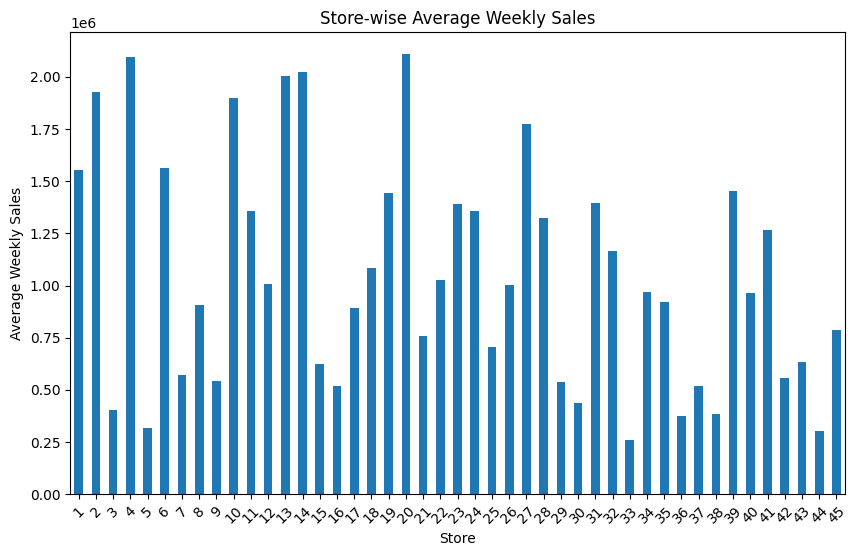

In [15]:
import matplotlib.pyplot as plt

# Calculate average weekly sales for each store
avg_sales = df.groupby("Store")["Weekly_Sales"].mean()

# Create bar chart
plt.figure(figsize=(10, 6))

avg_sales.plot(kind="bar")

plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.title("Store-wise Average Weekly Sales")
plt.xticks(rotation=45)
plt.show()

In [16]:
corr = df[[
    "Weekly_Sales",
    "Temperature"
]].corr()

print(corr)

              Weekly_Sales  Temperature
Weekly_Sales       1.00000     -0.06381
Temperature       -0.06381      1.00000


In [17]:
corr = df[[
    "Weekly_Sales",
    "Fuel_Price"
]].corr()

print(corr)

              Weekly_Sales  Fuel_Price
Weekly_Sales      1.000000    0.009464
Fuel_Price        0.009464    1.000000
